In [1]:
import sys
from pathlib import Path

import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean as cmo
plt.style.use('src/ryan_mplstyle.mplstyle')

import xarray as xr

from scipy.signal import convolve2d
from scipy.signal.windows import hamming

SRC_DIR = (Path.cwd() /'src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from draw_gaussian_field_from_spectrum import draw_gaussian_field_from_spectrum
from matern_spectral_density_2d import matern_spectral_density_2d

In [2]:
# Define a SWOT swath of 50x500 km
# With 250 m posting
Lx, Ly = 50, 500  # km
dx, dy = 0.25, 0.25  # km
# Grid for 2km posting (for downsampling after filtering)
dy_2km = 2  # km

Nx, Ny = int(Lx / dx), int(Ly / dy)
Lx, Ly = dx * Nx, dy * Ny

k = np.fft.fftfreq(Nx, d=dx)
l = np.fft.fftfreq(Ny, d=dy)
k_mat, l_mat = np.meshgrid(k, l)
Ka_mat = np.sqrt(k_mat**2 + l_mat**2)
x = np.arange(-Lx / 2, Lx / 2, Lx / Nx)
y = np.arange(-Ly / 2, Ly / 2, Ly / Ny)
x_mat, y_mat = np.meshgrid(x, y)

l_2km = np.fft.fftfreq(int(Ly/dy_2km), d=dy_2km)
downsample_stride = int(round(dy_2km / dy))

repeat_num = 2000 # total ensumble number
repeat_batch_size = 100 # processed in smaller batch size to fit in memory
batch_sizes = [repeat_batch_size] * (repeat_num // repeat_batch_size)
if repeat_num % repeat_batch_size:
    batch_sizes.append(repeat_num % repeat_batch_size)

In [3]:
# Create a "Balanced" spectrum using the 2D Matern PSD;
# with nu=1.5 the small-scale slope is -5, which is -4 in isotropic and along-track spectra
Bal_spec = matern_spectral_density_2d(Ka_mat, 1.5, l=50) * 8
Bal_spec[0, 0] = 0

In [4]:
# Keep noise fixed at the SWH = 4 m case
noise_mag_ref = np.array([1.77])**2/(0.96**2)

noisefloor_2km = 2*(15/0.5)/(2.3**2)
noise_spec_val = noisefloor_2km/(50/0.25)

# Base white-noise magnitude
base_noise_spec = np.ones(Bal_spec.shape) * noise_spec_val

# Load the crosstrack noise shape
nc_path = Path.cwd() / 'data' / 'SSHnoise_crosstrack.nc'
ds = xr.open_dataset(nc_path)
fit = ds['fit']

# We focus on the SWH=4m case
crosstrack_magnitude = np.asarray(fit.sel(swh=4))
crosstrack_magnitude = crosstrack_magnitude**2
crosstrack_magnitude /= np.mean(crosstrack_magnitude)
crosstrack_magnitude = crosstrack_magnitude**0.5

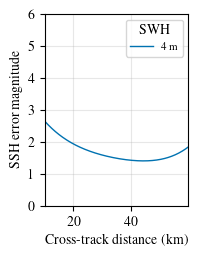

In [5]:
fig, ax = plt.subplots(figsize=(5 / 2.4, 6.4 / 2.4))

profile = fit.sel(swh=4)
ax.plot(x+35, np.flip(profile), label=f'{4} m')

ax.set_xlabel('Cross-track distance (km)')
ax.set_ylabel('SSH error magnitude')
ax.set_ylim(0,6)
ax.legend(loc='best', title='SWH')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Create the 2D 17 point Hamming window filter used in SWOT processing to create the 2km data
window_size = 17

# Create 1D Hamming window centered at (0,0)
hamm_1d = hamming(window_size)
# Create 2D filter using outer product and normalize it for convolution
hamm_filt2d = np.outer(hamm_1d, hamm_1d)
hamm_filt2d = hamm_filt2d / hamm_filt2d.sum()

In [7]:
# Bin in cross-track direction by 5 km
bin_km = 5
bin_pts = int(round(bin_km / dx))

n_cross_trim = ((Nx - 20) // bin_pts) * bin_pts
n_bins = n_cross_trim // bin_pts

# Running sums for ensumble averages.
filtered_spectra_sum = np.zeros((len(l), n_bins), dtype=float)
filtered_spectra2km_sum = np.zeros((len(l_2km), n_bins), dtype=float)

In [8]:
Noise_spec = base_noise_spec * noise_mag_ref
Tot_spec = Bal_spec + Noise_spec
Tot_spec[0, 0] = 0

In [9]:
start_idx = 0
for current_batch_size in batch_sizes:
    SSH_noise_hat, SSH_noise_batch = draw_gaussian_field_from_spectrum(
        Noise_spec, current_batch_size
    )
    SSH_noise_batch *= np.flip(crosstrack_magnitude)
    SSH_bal_hat, SSH_bal_batch = draw_gaussian_field_from_spectrum(Bal_spec, current_batch_size)
    SSH_batch = SSH_bal_batch + SSH_noise_batch

    SSH_filt = np.stack(
        [convolve2d(field, hamm_filt2d, mode='same', boundary='wrap') for field in SSH_batch],
        axis=0,
    )

    total_trim = SSH_filt[:, :, 10:-10]
    total_binned = total_trim.reshape(current_batch_size, Ny, n_bins, bin_pts).mean(axis=-1)
    total_trim2km = SSH_filt[:, 0::8, 10:-10]
    total_binned2km = total_trim2km.reshape(current_batch_size, int(Ny/8), n_bins, bin_pts).mean(axis=-1)

    filtered_spectra_sum += current_batch_size * np.mean(
        np.abs(np.fft.fft(total_binned, norm='forward', axis=1))**2, axis=0
    )
    filtered_spectra2km_sum += current_batch_size * np.mean(
        np.abs(np.fft.fft(total_binned2km, norm='forward', axis=1))**2, axis=0
    )

    start_idx += current_batch_size
    print(start_idx)

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000


In [10]:
# Averaged along-track spectra
filtered_spectra_by_noise = filtered_spectra_sum / repeat_num
filtered_spectra2km_by_noise = filtered_spectra2km_sum / repeat_num

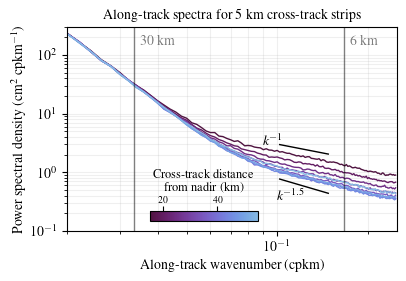

In [11]:
fig, ax = plt.subplots(figsize=(10 / 2.4, 7 / 2.4))

positive_wavenumber_2km = l_2km > 0

pos_order = np.arange(15,60,5)
pos_norm_lines = colors.Normalize(vmin=pos_order.min()-5, vmax=pos_order.max()+5+10)
pos_cmap = cmo.cm.dense_r
pos_colors = pos_cmap(pos_norm_lines(pos_order))

for idx, color in zip(range(filtered_spectra2km_by_noise.shape[1]), pos_colors):
    ax.loglog(
        l_2km[positive_wavenumber_2km],
        filtered_spectra2km_by_noise[positive_wavenumber_2km, idx],
        color=color,
    )

# Colorbar for SWH values
sm = plt.cm.ScalarMappable(cmap=pos_cmap, norm=pos_norm_lines)
sm.set_array([])
cax = ax.inset_axes([0.25, 0.05, 0.33, 0.05])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label('Cross-track distance\n from nadir (km)', fontsize=9)
cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.set_xlim(15, 55)
cbar.ax.tick_params(labelsize=7, pad=1)

# Reference slopes for visual comparison
l_ref = l_2km[(l_2km > 10e-2) & (l_2km < 0.15)]
ax.loglog(l_ref, l_ref**(-1) / 3.3, '-', color='k')
ax.text(9e-2, 3, r'$k^{-1}$', color='k')
ax.loglog(l_ref, l_ref**(-1.5) / 40, '-', color='k')
ax.text(10e-2, 0.35, r'$k^{-1.5}$', color='k')

# Annotate the 6 km and 30 km wavenumbers
ax.axvline(1 / 30, color='black', alpha=0.5)
ax.axvline(1 / 6, color='black', alpha=0.5)
ax.text(1 / 30 * 1.05, 220, '30 km', verticalalignment='top', alpha=0.5)
ax.text(1 / 6 * 1.05, 220, '6 km', verticalalignment='top', alpha=0.5)

ax.set_xlabel('Along-track wavenumber (cpkm)')
ax.set_ylabel(r'Power spectral density (cm$^2$ cpkm$^{-1}$)')
ax.set_title('Along-track spectra for 5 km cross-track strips')
ax.grid(True, which='both', alpha=0.2)
ax.set_xlim([2e-2, 1 / 4])
ax.set_ylim([1e-1, 3e2])

fig.tight_layout()
plt.savefig('figs/Hamm_cross.pdf', bbox_inches='tight')
plt.show()